<a href="https://colab.research.google.com/github/nandamanohar/ICT-intermediate-assessment-and-case-study/blob/main/ACTIVITY_on_Boosting_%26_Bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
loan=pd.read_csv('/content/loan_dataset.csv')
loan.head()

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m4,m5,m6,m7,m8,m9,m10,m11,m12,m13
0,268055008619,Z,"Turner, Baldwin and Rhodes",4.250,214000,360,2012-03-01,05/2012,95,1.0,...,0,0,0,1,0,0,0,0,0,1.0
1,672831657627,Y,"Swanson, Newton and Miller",4.875,144000,360,2012-01-01,03/2012,72,1.0,...,0,0,0,0,0,0,0,1,0,1.0
2,742515242108,Z,Thornton-Davis,3.250,366000,180,2012-01-01,03/2012,49,1.0,...,0,0,0,0,0,0,0,0,0,1.0
3,601385667462,X,OTHER,4.750,135000,360,2012-02-01,04/2012,46,2.0,...,0,0,0,0,0,1,1,1,1,1.0
4,273870029961,X,OTHER,4.750,124000,360,2012-02-01,04/2012,80,1.0,...,3,4,5,6,7,8,9,10,11,1.0


# data understanding


In [4]:
loan.shape

(33623, 29)

In [5]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33623 entries, 0 to 33622
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   33623 non-null  int64  
 1   source                    33623 non-null  object 
 2   financial_institution     33623 non-null  object 
 3   interest_rate             33623 non-null  float64
 4   unpaid_principal_bal      33623 non-null  int64  
 5   loan_term                 33623 non-null  int64  
 6   origination_date          33623 non-null  object 
 7   first_payment_date        33623 non-null  object 
 8   loan_to_value             33623 non-null  int64  
 9   number_of_borrowers       33623 non-null  float64
 10  debt_to_income_ratio      33623 non-null  float64
 11  borrower_credit_score     33623 non-null  float64
 12  loan_purpose              33623 non-null  object 
 13  insurance_percent         33623 non-null  float64
 14  co-bor

In [93]:
loan['origination_date'] = pd.to_datetime(loan['origination_date'])

In [6]:
loan['first_payment_date'] = pd.to_datetime(loan['first_payment_date'])

/tmp/ipykernel_3801/3364656723.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loan['first_payment_date'] = pd.to_datetime(loan['first_payment_date'])


In [96]:
loan['origination_year'] = loan['origination_date'].dt.year
loan['origination_month'] = loan['origination_date'].dt.month
loan['origination_day'] = loan['origination_date'].dt.day

In [97]:
loan.drop('origination_date', axis=1, inplace=True)

In [99]:
loan['payment_year'] = loan['first_payment_date'].dt.year
loan['payment_month'] = loan['first_payment_date'].dt.month
loan['payment_day'] = loan['first_payment_date'].dt.day

In [100]:
loan.drop('first_payment_date', axis=1, inplace=True)

In [101]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33622 entries, 0 to 33621
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   source                 33622 non-null  object 
 1   financial_institution  33622 non-null  object 
 2   interest_rate          33622 non-null  float64
 3   unpaid_principal_bal   33622 non-null  float64
 4   loan_term              33622 non-null  float64
 5   loan_to_value          33622 non-null  float64
 6   number_of_borrowers    33622 non-null  float64
 7   debt_to_income_ratio   33622 non-null  float64
 8   borrower_credit_score  33622 non-null  float64
 9   loan_purpose           33622 non-null  object 
 10  insurance_percent      33622 non-null  float64
 11  insurance_type         33622 non-null  float64
 12  m1                     33622 non-null  int64  
 13  m2                     33622 non-null  int64  
 14  m3                     33622 non-null  int64  
 15  m4     

In [102]:
loan.describe()

,interest_rate,unpaid_principal_bal,loan_term,loan_to_value,number_of_borrowers,debt_to_income_ratio,borrower_credit_score,insurance_percent,insurance_type,m1,...,m10,m11,m12,m13,origination_year,origination_month,origination_day,payment_year,payment_month,payment_day
count,3.362200e+04,3.362200e+04,3.362200e+04,3.362200e+04,3.362200e+04,3.362200e+04,3.362200e+04,3.362200e+04,3.362200e+04,33622.000000,...,33622.000000,33622.000000,33622.000000,33622.000000,33622.0,33622.000000,33622.0,33622.0,33622.000000,33622.0
mean,-7.657640e-16,1.037643e-16,-2.719852e-16,-2.211596e-16,-1.693831e-16,1.804253e-16,3.037907e-16,-1.014397e-17,-3.169990e-19,0.003985,...,0.016477,0.019154,0.023526,0.018916,2012.0,1.706145,1.0,2012.0,3.712361,1.0
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,0.070576,...,0.253636,0.284206,0.321095,0.136231,0.0,0.681450,0.0,0.0,0.692502,0.0
min,-2.860155e+00,-1.704174e+00,-2.470489e+00,-3.545057e+00,-1.190278e+00,-3.068559e+00,-7.248998e+00,-3.428778e-01,-5.597087e-02,0.000000,...,0.000000,0.000000,0.000000,0.000000,2012.0,1.000000,1.0,2012.0,2.000000,1.0
25%,-8.107442e-01,-7.765612e-01,-1.255067e+00,-5.990532e-01,-1.190278e+00,-8.082903e-01,-5.119091e-01,-3.428778e-01,-5.597087e-02,0.000000,...,0.000000,0.000000,0.000000,0.000000,2012.0,1.000000,1.0,2012.0,3.000000,1.0
50%,9.020287e-03,-2.077419e-01,7.520522e-01,2.674185e-01,8.401396e-01,1.362546e-02,2.895289e-01,-3.428778e-01,-5.597087e-02,0.000000,...,0.000000,0.000000,0.000000,0.000000,2012.0,2.000000,1.0,2012.0,4.000000,1.0
75%,5.555300e-01,6.236093e-01,7.520522e-01,7.295368e-01,8.401396e-01,8.355412e-01,7.403378e-01,-3.428778e-01,-5.597087e-02,0.000000,...,0.000000,0.000000,0.000000,0.000000,2012.0,2.000000,1.0,2012.0,4.000000,1.0
max,2.604941e+00,5.121657e+00,7.520522e-01,1.711538e+00,8.401396e-01,3.095809e+00,1.767180e+00,3.990860e+00,1.786644e+01,3.000000,...,12.000000,13.000000,14.000000,1.000000,2012.0,3.000000,1.0,2012.0,5.000000,1.0


In [95]:
loan.select_dtypes(include='object').columns

Index(['source', 'financial_institution', 'loan_purpose'], dtype='object')

# missing values

In [10]:
loan.isna().sum()

,0
loan_id,0
source,0
financial_institution,0
interest_rate,0
unpaid_principal_bal,0
loan_term,0
origination_date,0
first_payment_date,0
loan_to_value,0
number_of_borrowers,0


In [11]:
loan['co-borrower_credit_score'].unique()

array([  0., 638., 700., 770., 813., 658., 742., 736., 729., 625., 753.,
       759., 722., 680., 732., 780., 787., 766., 702., 785., 788., 697.,
       731., 685., 738., 699., 760., 668., 656., 671., 726., 781., 660.,
       718., 693., 808., 666., 648., 696., 804., 703., 704., 694., 777.,
       728., 687., 674., 644., 801., 727., 786., 657., 756., 774., 768.,
       795., 775., 715., 716., 810., 761., 806., 749., 802., 637., 772.,
       765., 667., 767., 714., 633., 698., 776., 798., 707., 659., 744.,
       683., 800., 809., 675., 670., 792., 673., 720., 711., 807., 689.,
       750., 754., 725., 789., 799., 663., 752., 672., 745., 665., 763.,
       684., 796., 635., 793., 782., 695., 764., 647., 721., 712., 740.,
       779., 664., 723., 628., 812., 790., 762., 719., 817., 640., 805.,
       677., 690., 771., 661., 713., 686., 730., 645., 755., 773., 784.,
       797., 803., 739., 814., 819., 791., 815., 794., 751., 778., 820.,
       816., 758., 811., 743., 821., 757., 783., 74

In [12]:
loan['co-borrower_credit_score'] = loan['co-borrower_credit_score'].replace(0, np.nan)

In [13]:
loan['co-borrower_credit_score'].isna().sum()

np.int64(13926)

In [14]:
loan = loan.drop('co-borrower_credit_score', axis=1)

In [15]:
loan['borrower_credit_score'].unique()

array([694., 697., 780., 633., 681., 675., 723., 652., 808., 702., 738.,
       742., 739., 757., 687., 731., 699., 669., 711., 640., 621., 746.,
       667., 779., 807., 683., 776., 747., 630., 661., 759., 650., 686.,
       741., 802., 726., 801., 627., 648., 641., 692., 678., 789., 758.,
       679., 740., 729., 733., 626., 790., 778., 787., 714., 783., 795.,
       672., 771., 764., 784., 685., 684., 654., 775., 727., 712., 761.,
       691., 701., 773., 716., 777., 753., 689., 696., 709., 760., 668.,
       635., 703., 677., 743., 786., 768., 665., 639., 717., 637., 809.,
       674., 676., 756., 737., 806., 700., 763., 659., 707., 730., 719.,
       798., 673., 643., 645., 666., 663., 657., 658., 660., 744., 680.,
       811., 813., 804., 734., 728., 705., 770., 749., 794., 793., 785.,
       664., 754., 721., 646., 755., 688., 655., 769., 799., 810., 708.,
       821., 796., 670., 788., 745., 629., 698., 765., 624., 682., 695.,
       750., 735., 706., 690., 767., 766., 815., 77

In [16]:
loan['borrower_credit_score'] = loan['borrower_credit_score'].replace(0, np.nan)

In [17]:
loan['borrower_credit_score'].isna().sum()

np.int64(13)

In [18]:
loan['borrower_credit_score'] = loan['borrower_credit_score'].fillna(
    loan['borrower_credit_score'].median())

In [19]:
loan['borrower_credit_score'].isna().sum()

np.int64(0)

In [20]:
loan['loan_id'].nunique()

33623

In [21]:
loan=loan.drop('loan_id',axis=1)

In [103]:
loan.head()

,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,loan_to_value,number_of_borrowers,debt_to_income_ratio,borrower_credit_score,loan_purpose,...,m10,m11,m12,m13,origination_year,origination_month,origination_day,payment_year,payment_month,payment_day
0,Z,"Turner, Baldwin and Rhodes",0.828785,0.046039,0.752052,1.596008,-1.190278,-0.911030,-1.889381,C86,...,0,0,0,1.0,2012,3,1,2012,5,1
1,Y,"Swanson, Newton and Miller",2.195059,-0.566536,0.752052,0.267419,-1.190278,1.349239,-1.814246,B12,...,0,1,0,1.0,2012,1,1,2012,3,1
2,Z,Thornton-Davis,-1.357254,1.376201,-1.255067,-1.061171,-1.190278,0.219104,0.264484,B12,...,0,0,0,1.0,2012,1,1,2012,3,1
3,X,OTHER,1.921804,-0.645295,0.752052,-1.234466,0.840140,1.349239,-3.417122,B12,...,1,1,1,1.0,2012,2,1,2012,4,1
4,X,OTHER,1.921804,-0.741557,0.752052,0.729537,-1.190278,1.246499,-2.214965,C86,...,9,10,11,1.0,2012,2,1,2012,4,1


# Outlier Handling

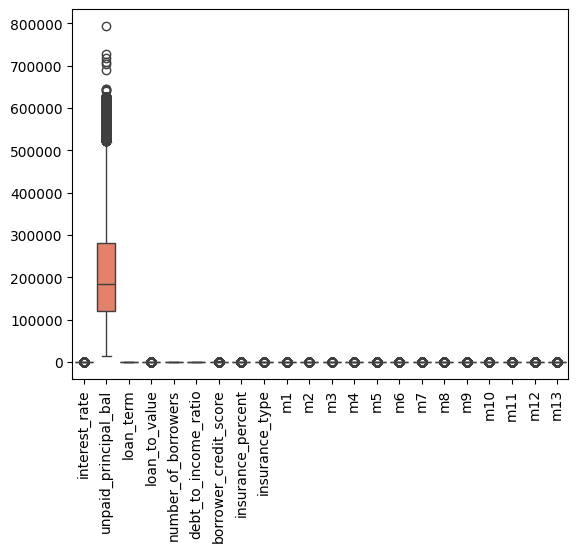

In [23]:
sns.boxplot(loan)
plt.xticks(rotation=90)
plt.show()

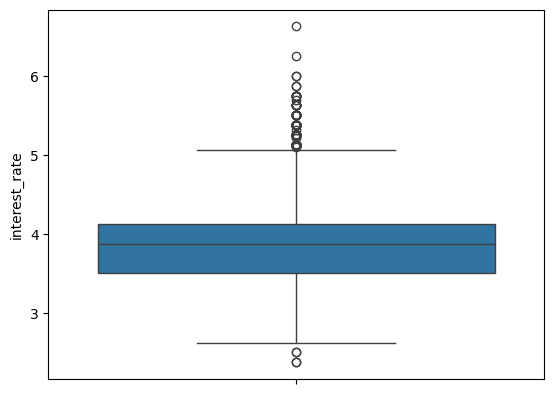

In [24]:
sns.boxplot(loan['interest_rate'])
plt.show()

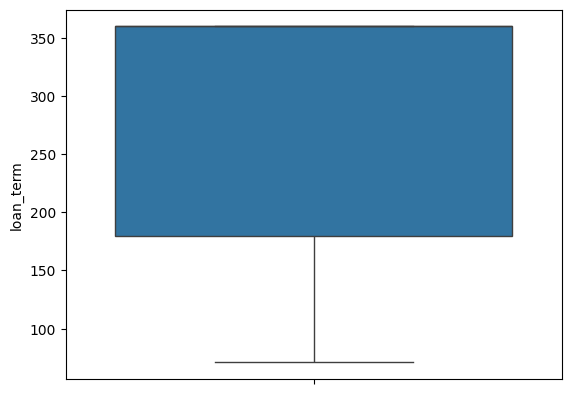

In [25]:
sns.boxplot(loan['loan_term'])
plt.show()

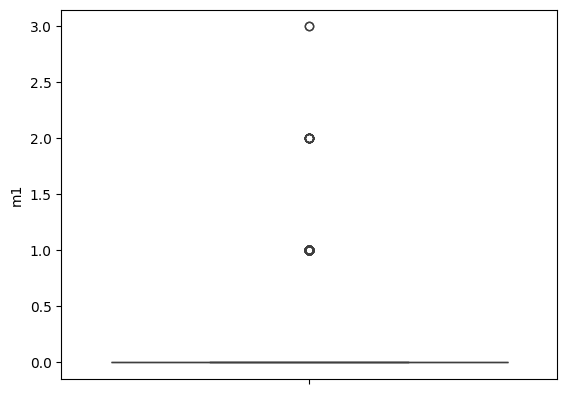

In [26]:
sns.boxplot(loan['m1'])
plt.show()

In [27]:
q1 = loan['interest_rate'].quantile(0.25)
q3 = loan['interest_rate'].quantile(0.75)

print(f'Q1 = {q1}\nQ3 = {q3}')

iqr = q3 - q1

up_lim_interest_rate = q3 + (1.5 * iqr)
low_lim_interest_rate = q1 - (1.5 * iqr)

print(f'IQR = {iqr}\nUp_lim = {up_lim_interest_rate}\nLow_lim = {low_lim_interest_rate}')

Q1 = 3.5
Q3 = 4.125
IQR = 0.625
Up_lim = 5.0625
Low_lim = 2.5625


In [28]:
outliers_interest_rate = loan[(loan['interest_rate'] > up_lim_interest_rate) | (loan['interest_rate'] < low_lim_interest_rate)]
outliers_interest_rate

,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,debt_to_income_ratio,...,m4,m5,m6,m7,m8,m9,m10,m11,m12,m13
14,Y,Edwards-Hoffman,5.125,84000,360,2012-02-01,2012-04-01,80,1.0,46.0,...,0,0,0,0,0,0,0,0,0,1.0
39,X,"Swanson, Newton and Miller",5.500,42000,360,2012-01-01,2012-03-01,79,1.0,33.0,...,0,0,0,0,1,1,2,2,1,1.0
61,X,"Miller, Mcclure and Allen",5.125,98000,360,2012-03-01,2012-05-01,35,1.0,45.0,...,0,0,0,0,0,0,0,0,1,1.0
73,X,OTHER,5.250,64000,360,2012-01-01,2012-03-01,73,1.0,49.0,...,0,2,3,2,0,1,1,2,3,1.0
88,Y,Browning-Hart,5.125,207000,360,2012-01-01,2012-03-01,75,1.0,18.0,...,0,0,0,1,2,3,4,5,6,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32704,Z,Edwards-Hoffman,5.101,120000,360,2012-01-01,2012-03-01,60,2.0,30.0,...,0,0,0,0,0,0,0,0,0,0.0
33215,X,OTHER,5.125,68000,360,2012-03-01,2012-05-01,97,2.0,40.0,...,0,0,0,0,0,0,0,0,0,0.0
33362,X,"Swanson, Newton and Miller",5.375,49000,360,2012-01-01,2012-03-01,75,1.0,47.0,...,0,0,0,0,0,0,0,0,0,0.0
33457,X,OTHER,5.125,64000,300,2012-01-01,2012-03-01,74,1.0,18.0,...,0,0,0,0,0,0,0,0,0,0.0


In [29]:
loan.loc[loan['interest_rate'] > up_lim_interest_rate,'interest_rate'] = up_lim_interest_rate
loan.loc[loan['interest_rate'] < low_lim_interest_rate,'interest_rate'] = low_lim_interest_rate

In [30]:
loan['interest_rate'].unique()

array([4.25  , 4.875 , 3.25  , 4.75  , 4.375 , 4.    , 4.5   , 4.125 ,
       3.75  , 4.625 , 5.0625, 3.375 , 3.99  , 4.312 , 3.875 , 3.5   ,
       3.33  , 5.    , 3.625 , 2.875 , 3.46  , 3.98  , 3.928 , 3.95  ,
       4.05  , 3.125 , 3.    , 3.74  , 3.709 , 4.3   , 4.99  , 4.225 ,
       4.28  , 4.58  , 4.9   , 4.49  , 4.1   , 3.856 , 4.54  , 3.77  ,
       3.504 , 3.958 , 4.06  , 3.87  , 3.1   , 3.94  , 4.124 , 4.015 ,
       2.95  , 3.167 , 3.835 , 3.938 , 3.503 , 3.438 , 3.49  , 3.24  ,
       4.19  , 3.902 , 4.46  , 3.289 , 3.978 , 4.03  , 4.358 , 2.99  ,
       3.795 , 3.074 , 3.91  , 2.975 , 3.71  , 2.75  , 4.08  , 4.876 ,
       3.185 , 3.35  , 4.2   , 4.864 , 3.613 , 3.865 , 4.917 , 3.908 ,
       3.337 , 3.92  , 2.625 , 3.43  , 3.65  , 4.17  , 3.85  , 3.985 ,
       2.775 , 3.79  , 3.67  , 3.947 , 4.048 , 2.8   , 3.17  , 4.21  ,
       4.849 , 3.83  , 4.521 , 3.852 , 3.943 , 3.999 , 3.972 , 3.18  ,
       3.476 , 4.986 , 3.42  , 3.2   , 4.119 , 3.175 , 3.41  , 3.145 ,
      

In [31]:
#outlier count
numeric_cols = loan.select_dtypes(include=['int64', 'float64']).columns

# Remove target column
numeric_cols = numeric_cols.drop('m13')

for col in numeric_cols:
    Q1 = loan[col].quantile(0.25)
    Q3 = loan[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_count = ((loan[col] < lower_limit) | (loan[col] > upper_limit)).sum()

    print(f"{col}: {outlier_count} outliers")

interest_rate: 0 outliers
unpaid_principal_bal: 468 outliers
loan_term: 0 outliers
loan_to_value: 465 outliers
number_of_borrowers: 0 outliers
debt_to_income_ratio: 0 outliers
borrower_credit_score: 1073 outliers
insurance_percent: 3915 outliers
insurance_type: 105 outliers
m1: 119 outliers
m2: 95 outliers
m3: 94 outliers
m4: 116 outliers
m5: 171 outliers
m6: 157 outliers
m7: 190 outliers
m8: 211 outliers
m9: 241 outliers
m10: 265 outliers
m11: 298 outliers
m12: 368 outliers


In [32]:
cols = [
    'unpaid_principal_bal',
    'loan_to_value',
    'borrower_credit_score',
    'insurance_percent'
]

for col in cols:
    print("\n", col)
    print("Min:", loan[col].min())
    print("Max:", loan[col].max())
    print("Q1:", loan[col].quantile(0.25))
    print("Q3:", loan[col].quantile(0.75))


 unpaid_principal_bal
Min: 14000
Max: 794000
Q1: 120000.0
Q3: 280000.0

 loan_to_value
Min: 6
Max: 97
Q1: 57.0
Q3: 80.0

 borrower_credit_score
Min: 480.0
Max: 840.0
Q1: 749.0
Q3: 799.0

 insurance_percent
Min: 0.0
Max: 35.0
Q1: 0.0
Q3: 0.0


In [33]:
(loan['borrower_credit_score'] == 0).sum()

np.int64(0)

In [34]:
loan['borrower_credit_score'].value_counts().head(10)

,count
borrower_credit_score,
809.0,652
801.0,642
802.0,591
808.0,587
791.0,569
804.0,547
800.0,542
798.0,535
797.0,526


# encodinggg

In [104]:
loan.select_dtypes(include='object').columns

Index(['source', 'financial_institution', 'loan_purpose'], dtype='object')

In [105]:
for col in loan.select_dtypes(include='object').columns:
    print("\n", col)
    print(loan[col].unique()[:10])


 source
['Z' 'Y' 'X']

 financial_institution
['Turner, Baldwin and Rhodes' 'Swanson, Newton and Miller'
 'Thornton-Davis' 'OTHER' 'Browning-Hart' 'Richardson Ltd'
 'Edwards-Hoffman' 'Richards-Walters' 'Martinez, Duffy and Bird'
 'Miller, Mcclure and Allen']

 loan_purpose
['C86' 'B12' 'A23']


In [106]:
cate_cols = loan.select_dtypes(include=['object']).columns

print(cate_cols)

Index(['source', 'financial_institution', 'loan_purpose'], dtype='object')


In [107]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = encoder.fit_transform(loan[cate_cols])

In [108]:
encoded_data.shape

(33622, 25)

In [109]:
#to confirm encoding
print("Original categorical columns:")
print(loan[cate_cols].head())

print("\nEncoded column names:")
print(encoder.get_feature_names_out(cate_cols))

Original categorical columns:
  source       financial_institution loan_purpose
0      Z  Turner, Baldwin and Rhodes          C86
1      Y  Swanson, Newton and Miller          B12
2      Z              Thornton-Davis          B12
3      X                       OTHER          B12
4      X                       OTHER          C86

Encoded column names:
['source_X' 'source_Y' 'source_Z' 'financial_institution_Anderson-Taylor'
 'financial_institution_Browning-Hart'
 'financial_institution_Chapman-Mcmahon'
 'financial_institution_Cole, Brooks and Vincent'
 'financial_institution_Edwards-Hoffman'
 'financial_institution_Martinez, Duffy and Bird'
 'financial_institution_Miller, Mcclure and Allen'
 'financial_institution_Nicholson Group' 'financial_institution_OTHER'
 'financial_institution_Richards-Walters'
 'financial_institution_Richardson Ltd'
 'financial_institution_Romero, Woods and Johnson'
 'financial_institution_Sanchez, Hays and Wilkerson'
 'financial_institution_Sanchez-Robinson'
 '

In [110]:
#target feature splitting
X = loan.drop('m13', axis=1)
y = loan['m13']

In [111]:
print(X.shape)
print(y.shape)

(33622, 30)
(33622,)


In [112]:
print(encoded_data.dtype)

float64


In [61]:
# Drop the row where target 'm13' has NaN
loan = loan.dropna(subset=['m13'])
X = loan.drop('m13', axis=1)
y = loan['m13']


In [62]:
# This tells us how many 0s and 1s are in m13.
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

m13
0.0    26388
1.0      509
Name: count, dtype: int64
m13
0.0    0.981076
1.0    0.018924
Name: proportion, dtype: float64


# scaling

In [114]:
loan.select_dtypes(include=['float','int']).columns

Index(['interest_rate', 'unpaid_principal_bal', 'loan_term', 'loan_to_value',
       'number_of_borrowers', 'debt_to_income_ratio', 'borrower_credit_score',
       'insurance_percent', 'insurance_type', 'm1', 'm2', 'm3', 'm4', 'm5',
       'm6', 'm7', 'm8', 'm9', 'm10', 'm11', 'm12', 'm13', 'origination_year',
       'origination_month', 'origination_day', 'payment_year', 'payment_month',
       'payment_day'],
      dtype='object')

In [115]:
scale_cols = ['interest_rate',
    'unpaid_principal_bal',
    'loan_term',
    'loan_to_value',
    'number_of_borrowers',
    'debt_to_income_ratio',
    'borrower_credit_score',
    'insurance_percent','insurance_type']

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
loan[scale_cols] = scaler.fit_transform(loan[scale_cols])

In [51]:
from sklearn.metrics import confusion_matrix,precision_score
from sklearn.metrics import accuracy_score,f1_score
from sklearn.metrics import recall_score

In [68]:
# Drop categorical and datetime columns
features_numeric = loan.drop(columns=['source', 'financial_institution', 'loan_purpose', 'origination_date', 'first_payment_date', 'm13'])

# Ensure encoded_loan matches the indices of the filtered loan DataFrame
encoded_loan_aligned = encoded_loan.loc[loan.index]

# Concatenate aligned one-hot encoded columns
X_final = pd.concat([features_numeric, encoded_loan_aligned], axis=1)
y_final = loan['m13']

# Re-split the dataset with completely numeric features
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# logistics regression

In [65]:
#logistics regression model
from sklearn.linear_model import LogisticRegression

In [70]:
lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(X_train, y_train)
y_pred_lr_model = lr_model.predict(X_test)

In [116]:
print(confusion_matrix(y_test, y_pred_lr_model))
print('Accuracy is:',accuracy_score(y_test,y_pred_lr_model))
print('Precision is:',precision_score(y_test,y_pred_lr_model))
print('Recall is:',recall_score(y_test,y_pred_lr_model))
print('F1 score is',f1_score(y_test,y_pred_lr_model))

[[6589    9]
 [  71   56]]
Accuracy is: 0.9881040892193309
Precision is: 0.8615384615384616
Recall is: 0.4409448818897638
F1 score is 0.5833333333333334


# KNN

In [117]:
#kNN
#Finding the optimum k value
from sklearn.neighbors import KNeighborsClassifier

acc_score = []
for i in range(3,10):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train,y_train)
  y_pred_knn = knn.predict(x_test)
  acc = accuracy_score(y_test,y_pred_knn)
  acc_score.append(acc)

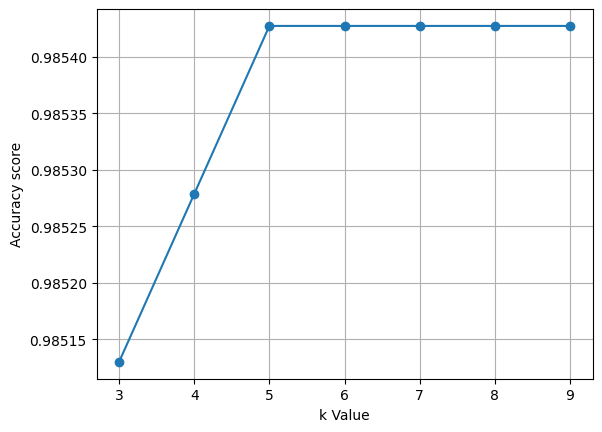

In [118]:
plt.plot(np.arange(3,10),acc_score,'o-')  #o- kodutha becoz points plot avan vendi

plt.xlabel('k Value')
plt.ylabel('Accuracy score')
plt.grid()

In [119]:
#optimum k value is 5 becoz accuracy is high when k =5
#train the knn model for k=5

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(confusion_matrix(y_test, y_pred_knn))
print('Accuracy is:', accuracy_score(y_test, y_pred_knn))
print('Precision is:', precision_score(y_test, y_pred_knn))
print('Recall is:', recall_score(y_test, y_pred_knn))
print('F1 score is', f1_score(y_test, y_pred_knn))

[[6597    1]
 [  97   30]]
Accuracy is: 0.9854275092936803
Precision is: 0.967741935483871
Recall is: 0.23622047244094488
F1 score is 0.379746835443038


# SVM

In [73]:
from sklearn.svm import SVC

In [120]:
#linear kernel
svm_linear = SVC(kernel='linear')    #kernel='linear' is a hyperparameter
svm_linear.fit(x_train,y_train)
y_pred_svm_linear = svm_linear.predict(x_test)
print(confusion_matrix(y_test,y_pred_svm_linear))
print(accuracy_score(y_test,y_pred_svm_linear))
print(precision_score(y_test,y_pred_svm_linear))
print(recall_score(y_test,y_pred_svm_linear))
print(f1_score(y_test,y_pred_svm_linear))

[[6583   15]
 [  71   56]]
0.9872118959107806
0.7887323943661971
0.4409448818897638
0.5656565656565656


In [121]:
#polynomial kernel
svm_poly = SVC(kernel='poly')
svm_poly.fit(x_train,y_train)
y_pred_svm_poly = svm_poly.predict(x_test)
print(confusion_matrix(y_test,y_pred_svm_poly))
print(accuracy_score(y_test,y_pred_svm_poly))
print(precision_score(y_test,y_pred_svm_poly))
print(recall_score(y_test,y_pred_svm_poly))
print(f1_score(y_test,y_pred_svm_poly))

[[6584   14]
 [  76   51]]
0.9866171003717472
0.7846153846153846
0.4015748031496063
0.53125


In [122]:
#rbf kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(x_train,y_train)
y_pred_svm_rbf = svm_rbf.predict(x_test)
print(confusion_matrix(y_test,y_pred_svm_rbf))
print(accuracy_score(y_test,y_pred_svm_rbf))
print(precision_score(y_test,y_pred_svm_rbf))
print(recall_score(y_test,y_pred_svm_rbf))
print(f1_score(y_test,y_pred_svm_rbf))

[[6586   12]
 [  74   53]]
0.9872118959107806
0.8153846153846154
0.41732283464566927
0.5520833333333334


# decision Trees

In [123]:
#decision Trees
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',random_state=42)   #kernel='linear' is a hyperparameter
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print(confusion_matrix(y_test,y_pred_dt))
print(accuracy_score(y_test,y_pred_dt))
print(accuracy_score(y_test,y_pred_dt))
print(precision_score(y_test,y_pred_dt))
print(recall_score(y_test,y_pred_dt))
print(f1_score(y_test,y_pred_dt))

[[6487  111]
 [  67   60]]
0.9735315985130112
0.9735315985130112
0.3508771929824561
0.47244094488188976
0.40268456375838924


# Random Forest





In [124]:
# Random Forest Training
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(criterion='entropy', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Print metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
print(confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

[[6581   17]
 [  69   58]]
Accuracy: 0.9872118959107806
Precision: 0.7733333333333333
Recall: 0.4566929133858268
F1 Score: 0.5742574257425742


# adaboost(Adaptive learning)

In [89]:
#Adaboost (Adaptive learning)
from sklearn.ensemble import AdaBoostClassifier

In [125]:
adaboost_clf = AdaBoostClassifier(random_state=42)
adaboost_clf.fit(x_train, y_train)
y_pred_adaboost = adaboost_clf.predict(x_test)
print(confusion_matrix(y_test, y_pred_adaboost))
print('Accuracy', accuracy_score(y_test, y_pred_adaboost))
print('Precision', precision_score(y_test, y_pred_adaboost))
print('recall_score', recall_score(y_test, y_pred_adaboost))
print('f1_score', f1_score(y_test, y_pred_adaboost))

[[6589    9]
 [  73   54]]
Accuracy 0.9878066914498141
Precision 0.8571428571428571
recall_score 0.4251968503937008
f1_score 0.5684210526315789


# gradient boost

In [87]:
#gradient boost
from sklearn.ensemble import GradientBoostingClassifier

In [88]:
gradboost_clf = GradientBoostingClassifier(random_state=42)
gradboost_clf.fit(x_train, y_train)
y_pred_gradboost = gradboost_clf.predict(x_test)
print('Accuracy = ', accuracy_score(y_test, y_pred_gradboost))
print('Precision = ', precision_score(y_test, y_pred_gradboost))
print('recall = ', recall_score(y_test, y_pred_gradboost))
print('f1 score = ', f1_score(y_test, y_pred_gradboost))
print(confusion_matrix(y_test, y_pred_gradboost))

Accuracy =  0.9858736059479554
Precision =  0.686046511627907
recall =  0.4645669291338583
f1 score =  0.5539906103286385
[[6571   27]
 [  68   59]]


# XGBoost (Extreme Gradient Boosting)

In [85]:
# XGBoost (Extreme Gradient Boosting)
import xgboost as xgb

In [126]:
xgboost_clf = xgb.XGBClassifier(random_state=42)
xgboost_clf.fit(x_train, y_train)
y_pred_xgboost = xgboost_clf.predict(x_test)
print('Accuracy = ', accuracy_score(y_test, y_pred_xgboost))
print('Precision = ', precision_score(y_test, y_pred_xgboost))
print('recall = ', recall_score(y_test, y_pred_xgboost))
print('f1 score = ', f1_score(y_test, y_pred_xgboost))
print(confusion_matrix(y_test, y_pred_xgboost))

Accuracy =  0.9875092936802974
Precision =  0.7792207792207793
recall =  0.47244094488188976
f1 score =  0.5882352941176471
[[6581   17]
 [  67   60]]


**XGBoost** as the best overall model.

Accuracy: 98.75%
Precision: 77.92%
Recall: 47.24%
F1-score: 58.82%

XGBoost has the **highest F1-score** and **highest recall** among your tested models.

Although Logistic Regression achieved slightly higher accuracy, XGBoost provided better recall and F1-score, making it more suitable for identifying positive cases in this imbalanced classification problem